# Pneumonia Detection from Chest X-Ray Images

This notebook presents a binary image classification project for detecting pneumonia in chest X-ray images.

The objective is not to create a clinical diagnostic tool, but to demonstrate a complete deep learning workflow suitable for a portfolio project: data loading, preprocessing, model training, evaluation, threshold tuning, and critical interpretation of results.

> **Disclaimer:** This project is for educational purposes only and should not be used for medical diagnosis.


## 1. Imports

The project uses TensorFlow/Keras for model training, NumPy and Pandas for data handling, Scikit-learn for evaluation utilities, and Matplotlib/Seaborn for visualization.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import seaborn as sns

## 2. Dataset loading and preprocessing

The dataset is stored in separate folders for `NORMAL` and `PNEUMONIA` images.

Each image is:

1. loaded from disk,
2. converted to grayscale,
3. resized to `224 x 224`,
4. normalized to the `[0, 1]` range,
5. reshaped to include a single channel dimension.

This gives each sample the shape `(224, 224, 1)`.


In [23]:
# Data collection
import os
from PIL import Image

test_dir = "../data/test"
train_dir = "../data/train"

labels = ["NORMAL", "PNEUMONIA"]

def load_dataset(dataset_path, labels = labels, img_size=224):

    X = []
    y = []

    valid_extensions = (".png", ".jpg", ".jpeg")

    for label, class_name in enumerate(labels):

        class_path = os.path.join(dataset_path, class_name)

        for img_name in os.listdir(class_path):

            if not img_name.lower().endswith(valid_extensions):
                continue

            img_path = os.path.join(class_path, img_name)

            try:

                with Image.open(img_path) as img:

                    # grayscale
                    img = img.convert("L")

                    # resize
                    img = img.resize((img_size, img_size))

                    # PIL -> numpy
                    img = np.array(img)

                    X.append(img)

                    y.append(label)

            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    X = np.array(X, dtype="float32")
    y = np.array(y)

    # normalization
    X = X / 255.0

    # add channel dimension
    X = X.reshape(-1, img_size, img_size, 1)

    return X, y

## 3. Reproducibility setup

Neural network training is stochastic. Randomness comes from weight initialization, dropout, data augmentation, and sometimes from backend-level operations.

To make the experiment more stable and easier to reproduce, random seeds are fixed for Python, NumPy, TensorFlow, and later also for the train/validation split and augmentation layers.


In [24]:
import random
import os

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 4. Train / validation / test split

The original `data/val` folder is very small, so it is not used as the main validation set. Instead, the training folder is split into training and validation subsets using a stratified split.

The separate test folder is kept untouched and used only for final evaluation.


In [25]:
from sklearn.model_selection import train_test_split

X_full_train, y_full_train = load_dataset(train_dir)
X_test, y_test = load_dataset(test_dir)

X_train, X_val, y_train, y_val = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.2,
    stratify=y_full_train,
    random_state=SEED
)

## 5. Dataset shapes

The following cells confirm the final array shapes for the training, validation, and test sets.


In [26]:
print(X_train.shape)
print(y_train.shape)

(4172, 224, 224, 1)
(4172,)


In [27]:
print(X_test.shape)
print(y_test.shape)

(624, 224, 224, 1)
(624,)


In [28]:
print(X_val.shape)
print(y_val.shape)

(1044, 224, 224, 1)
(1044,)


## 6. Class distribution

Medical image datasets are often imbalanced. Here, the pneumonia class is more frequent than the normal class, so it is important to inspect the class distribution before training.

This imbalance also explains why accuracy alone can be misleading: a model can achieve a seemingly reasonable score by over-predicting the majority class.


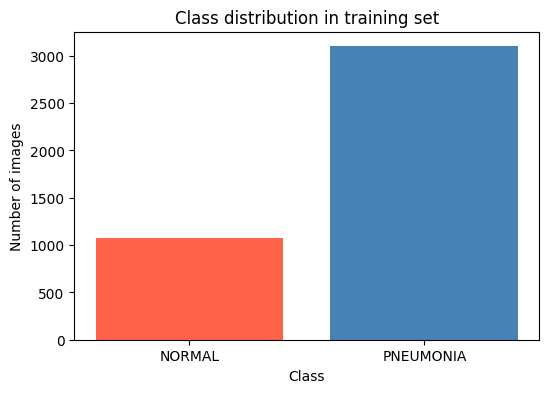

In [29]:
class_counts = np.bincount(y_train)

plt.figure(figsize=(6, 4))
plt.bar(labels, class_counts, color=["tomato", "steelblue"])

plt.title("Class distribution in training set")
plt.xlabel("Class")
plt.ylabel("Number of images")

plt.show()

## 7. Class weights experiment

Class weights are computed to quantify the class imbalance. They were tested during experimentation, but the final reported model does **not** use `class_weight` because it did not consistently improve the test-set behavior.

Keeping this cell in the notebook documents the experiment and makes it easy to reproduce the weighted variant if needed.


In [30]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print(class_weight)

{0: np.float64(1.9440820130475303), 1: np.float64(0.6731203614069055)}


## 8. Data augmentation

Light augmentation is applied during training to improve generalization. The transformations are intentionally conservative because chest X-ray images should not be distorted too aggressively.


In [31]:
# Data Augumentation
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05, seed=SEED),
    layers.RandomZoom(0.1, seed=SEED),
    layers.RandomTranslation(0.05, 0.05, seed=SEED),
    layers.RandomContrast(0.1, seed=SEED),
])

## 9. CNN architecture

The model is a custom convolutional neural network with three convolutional blocks followed by a dense classification head.

The final output layer uses a sigmoid activation because this is a binary classification task.

A `Flatten`-based head is used in the final version. A `GlobalAveragePooling2D` variant was considered, but this architecture performed better in the current experiment.


In [32]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 1)),

    data_augmentation,
    
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [33]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,132,641 (50.10 MB)

 Trainable params: 13,132,193 (50.10 MB)

 Non-trainable params: 448 (1.75 KB)

## 10. Compilation and callbacks

The model is trained with binary cross-entropy loss and the Adam optimizer.

In addition to accuracy, the notebook tracks precision, recall, and AUC. These metrics are especially important here because medical screening tasks should not be evaluated using accuracy alone.

Two callbacks are used:

- `EarlyStopping` to restore the best validation-loss model,
- `ReduceLROnPlateau` to reduce the learning rate when validation loss stops improving.


In [34]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy", "precision", "recall", "auc"]
)

In [35]:
# Callbacks
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

## 11. Model training

The final training run is performed **without class weights**. In previous experiments, class weighting increased the false-positive problem and did not provide a reliable improvement on the test set.


In [36]:
history = model.fit(
    X_train, 
    y_train, 
    epochs=30, 
    batch_size=64, 
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.6999 - auc: 0.5670 - loss: 4.7935 - precision: 0.7528 - recall: 0.8874 - val_accuracy: 0.7433 - val_auc: 0.5000 - val_loss: 0.5695 - val_precision: 0.7433 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.7428 - auc: 0.7071 - loss: 0.5200 - precision: 0.7428 - recall: 1.0000 - val_accuracy: 0.7433 - val_auc: 0.5000 - val_loss: 0.6086 - val_precision: 0.7433 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.7428 - auc: 0.7565 - loss: 0.4774 - precision: 0.7428 - recall: 1.0000 - val_accuracy: 0.7433 - val_auc: 0.4550 - val_loss: 0.7824 - val_precision: 0.7433 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7428 - auc: 0.7854 - loss: 0.4584 - precision: 0.7428 - recall: 1.0000 - val_accuracy: 0.7433 - val_auc: 0.3584 - val_loss: 0.6063 - val_precisi

## 12. Training curves

The loss and accuracy curves help diagnose underfitting, overfitting, and unstable validation behavior.

In this project, threshold-dependent metrics such as accuracy can look unusual during training because the model may initially predict most images as `PNEUMONIA` at the default threshold, while still improving its ranking ability as measured by AUC.


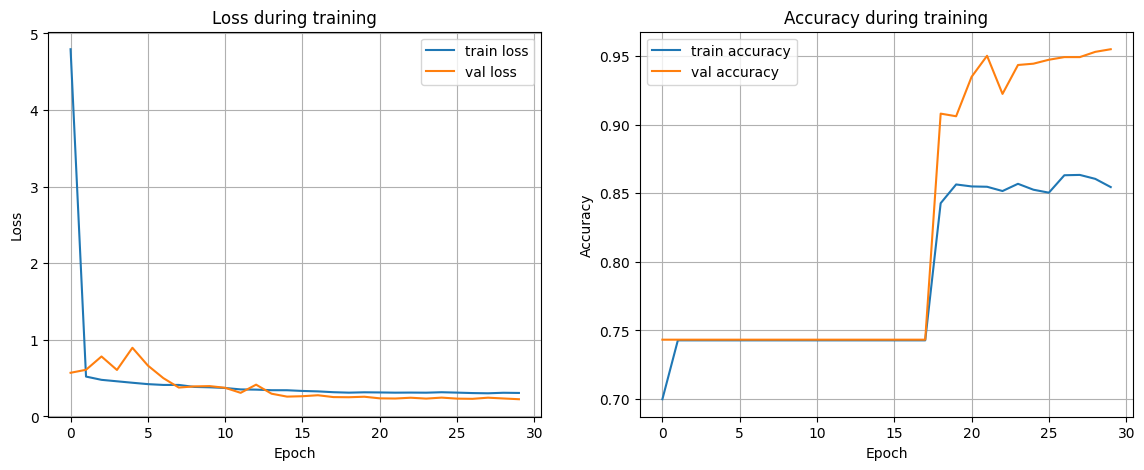

In [37]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train accuracy")
plt.plot(history_df["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy during training")
plt.legend()
plt.grid(True)

plt.show()

## 13. Test evaluation at the default threshold

Keras evaluates precision, recall, and accuracy using the default decision threshold of `0.5`.

In the final run, this threshold produces very high pneumonia recall, but the model still predicts too many normal X-rays as pneumonia. This is why the next sections analyze the confusion matrix and tune the decision threshold.


In [38]:
test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(X_test, y_test)

print(f"Test loss:      {test_loss:.4f}")
print(f"Test accuracy:  {test_accuracy:.4f}")
print(f"Test precision: {test_precision:.4f}")
print(f"Test recall:    {test_recall:.4f}")
print(f"Test AUC:       {test_auc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.7163 - auc: 0.9307 - loss: 0.8032 - precision: 0.6885 - recall: 0.9974
Test loss:      0.8032
Test accuracy:  0.7163
Test precision: 0.6885
Test recall:    0.9974
Test AUC:       0.9307


## 14. Confusion matrix at threshold `0.5`

The confusion matrix shows how many samples from each true class were assigned to each predicted class.

This is essential for this task because two models with similar accuracy can have very different medical meaning depending on their false-negative and false-positive rates.


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step


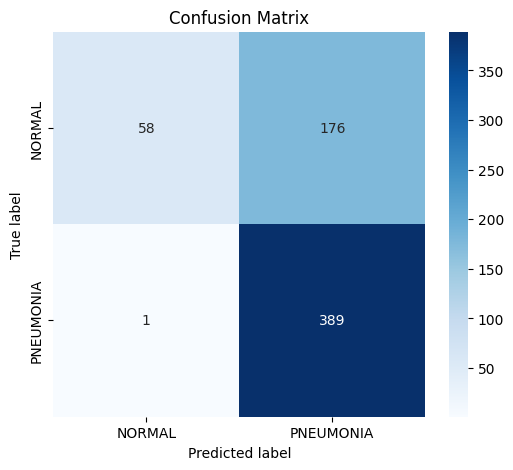

              precision    recall  f1-score   support

      NORMAL       0.98      0.25      0.40       234
   PNEUMONIA       0.69      1.00      0.81       390

    accuracy                           0.72       624
   macro avg       0.84      0.62      0.61       624
weighted avg       0.80      0.72      0.66       624



In [39]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(
    y_test,
    y_pred,
    target_names=labels
))

## 15. Threshold tuning on the validation set

The sigmoid output is not guaranteed to be a well-calibrated probability. Therefore, the default threshold `0.5` is not always the best operating point.

This section evaluates several thresholds on the validation set and selects the threshold with the best F1 score for the positive class (`PNEUMONIA`).


In [40]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_val_proba = model.predict(X_val).ravel()

thresholds = np.arange(0.1, 0.95, 0.05)

results = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred),
        "recall": recall_score(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred)
    })

threshold_df = pd.DataFrame(results)
threshold_df

33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step


,threshold,accuracy,precision,recall,f1
0,0.10,0.743295,0.743295,1.000000,0.852747
1,0.15,0.743295,0.743295,1.000000,0.852747
2,0.20,0.743295,0.743295,1.000000,0.852747
3,0.25,0.743295,0.743295,1.000000,0.852747
4,0.30,0.743295,0.743295,1.000000,0.852747
5,0.35,0.743295,0.743295,1.000000,0.852747
6,0.40,0.743295,0.743295,1.000000,0.852747
7,0.45,0.743295,0.743295,1.000000,0.852747
8,0.50,0.954981,0.961977,0.978093,0.969968
9,0.55,0.952107,0.966581,0.969072,0.967825


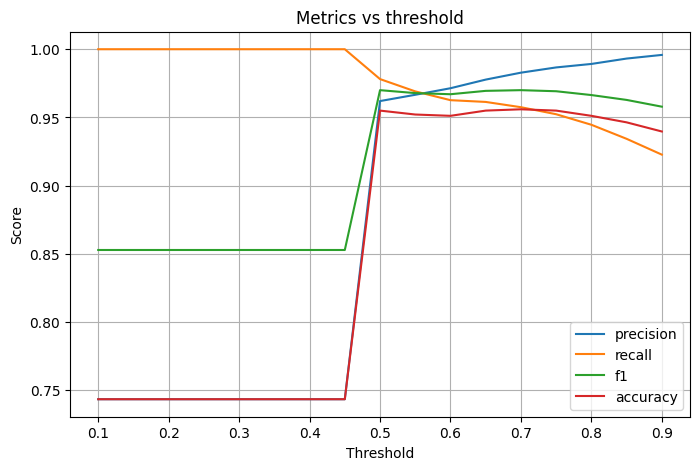

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="f1")
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="accuracy")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Metrics vs threshold")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
best_threshold = threshold_df.loc[
    threshold_df["f1"].idxmax(),
    "threshold"
]

best_threshold

np.float64(0.7000000000000002)

## 16. Final test evaluation with the selected threshold

The threshold selected on the validation set is then applied once to the held-out test set.

This gives a more realistic estimate of how the tuned decision rule performs on unseen data.


In [43]:
threshold = best_threshold

y_test_proba = model.predict(X_test).ravel()
y_test_pred = (y_test_proba >= threshold).astype(int)

print(f"Threshold: {threshold:.2f}")

print(classification_report(
    y_test,
    y_test_pred,
    target_names=labels
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step
Threshold: 0.70
              precision    recall  f1-score   support

      NORMAL       0.98      0.42      0.59       234
   PNEUMONIA       0.74      0.99      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.71      0.72       624
weighted avg       0.83      0.78      0.75       624



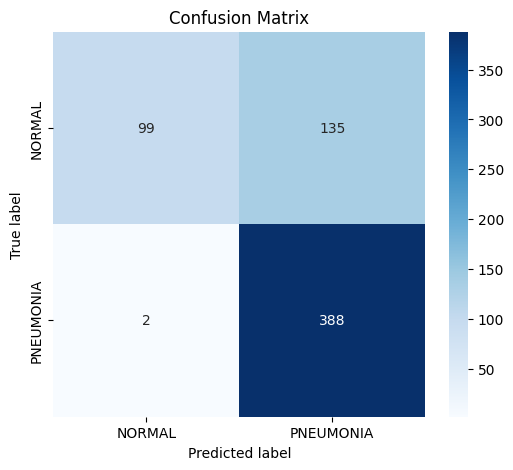

In [44]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

## 17. Interpretation of final results

The final model behaves like a high-sensitivity screening classifier:

- it detects almost all pneumonia cases,
- it has very high recall for the `PNEUMONIA` class,
- it still produces a significant number of false positives for the `NORMAL` class,
- its AUC suggests useful class-separation ability,
- threshold tuning improves the operating point compared with relying only on the default threshold.

This trade-off is important. In a medical screening context, missing pneumonia cases can be more costly than sending normal cases for additional review. However, because the false-positive rate is still high, this model should not be interpreted as a standalone diagnostic system.

The main value of this project is the full evaluation process: understanding class imbalance, checking confusion matrices, comparing thresholds, and explaining why accuracy alone is not enough for medical image classification.
